# Onset-HFO 3 — How good are these detectors, actually?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/berdakh/bci-gan/blob/master/onset-hfo/notebooks/03_validation_and_benchmark.ipynb)

The public recording has no HFO labels. Nobody has marked every ripple in it,
so on real data we can report rates, rankings and agreement, but **not**
precision and recall. Claiming otherwise would be the most common way
detection papers mislead.

So we build a recording where the truth is known: 1/f background, mains noise,
implanted ripples at a controlled signal-to-noise ratio, interictal discharges
(some with ripples riding on them, as in real epileptic tissue), and — most
importantly — **the traps**: large sharp transients that ring through an
80–250 Hz filter and look exactly like ripples.

Everything in this notebook runs offline in about a minute.

In [1]:
# Colab setup. On your own machine, skip this cell and run
#   pip install -e ".[dev]"  from the onset-hfo directory instead.
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO = "https://github.com/berdakh/bci-gan.git"
BRANCH = "master"   # the repository default branch

if IN_COLAB and not os.path.exists("bci-gan"):
    subprocess.run(["git", "clone", "-q", "--branch", BRANCH, "--depth", "1", REPO], check=True)
if IN_COLAB:
    os.chdir("/content/bci-gan/onset-hfo")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("working directory:", os.getcwd())

working directory: /home/user/bci-gan/onset-hfo


## 1. Build a labelled recording

In [2]:
from onset_hfo.synthetic import make_synthetic_recording

recording = make_synthetic_recording(duration_s=60, seed=7)
recording.ground_truth.groupby("kind").agg(
    n=("kind", "size"), mean_amplitude_uv=("amplitude_uv", "mean")).round(1)

[onset-hfo] synthetic recording: 18 contacts, 60 s @ 2000 Hz, 395 implanted events (hot contacts: SA2, SA3)


,n,mean_amplitude_uv
kind,,
artifact,68,1063.3
ripple,210,83.4
spike,117,343.5


In [3]:
print("\n".join(recording.notes))

synthetic recording, seed=7: 18 contacts, 60 s @ 2000 Hz
implanted: 210 ripples, 117 discharges, 68 artifacts
'hot' contacts with elevated rates: SA2, SA3
ground truth is known exactly; use onset_hfo.evaluate for precision/recall


The "hot" contacts carry ~20x the event rate of the others, and their rate
rises again inside a simulated seizure window. A detector that cannot find
them is not worth discussing.

## 2. Look at the traps

Three windows: a clean implanted ripple, a discharge, and an artifact. The
artifact has no oscillation of its own — but watch what the band-pass does
to it.

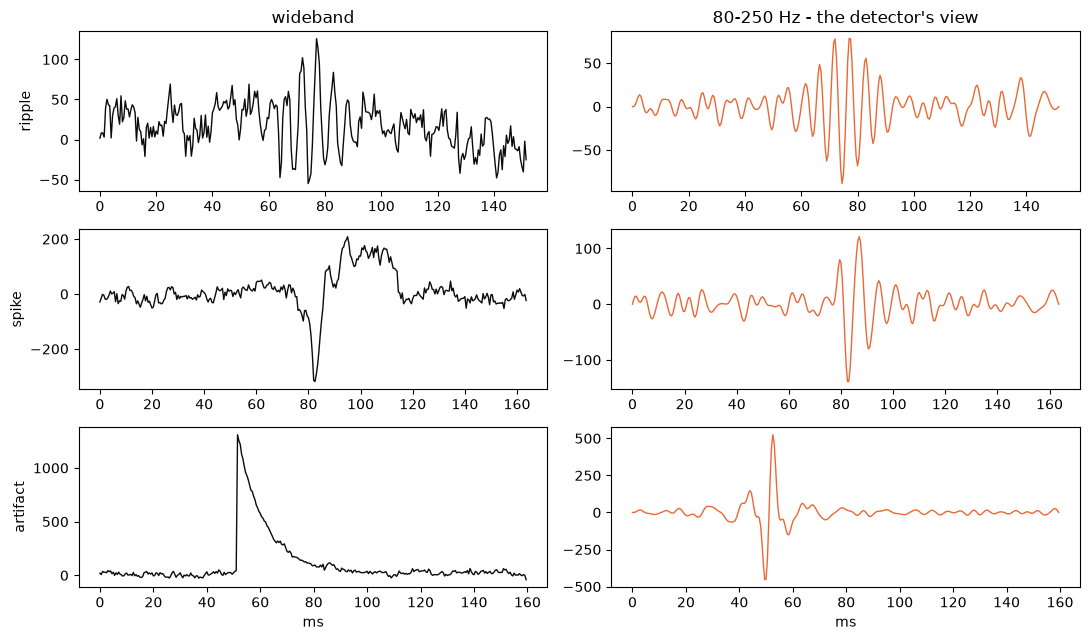

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from onset_hfo.detectors.base import bandpass

sf = recording.sfreq
raw = recording.raw.get_data() * 1e6
names = list(recording.ch_names)
gt = recording.ground_truth

fig, axes = plt.subplots(3, 2, figsize=(11, 6.5))
for row, kind in enumerate(["ripple", "spike", "artifact"]):
    event = gt[gt["kind"] == kind].iloc[3]
    ch = names.index(event["contact"])
    i0 = int((event["start"] - 0.05) * sf); i1 = int((event["stop"] + 0.05) * sf)
    seg = raw[ch, i0:i1]
    t = np.arange(seg.size) / sf * 1000
    axes[row, 0].plot(t, seg, color="#0b0b0b", linewidth=1)
    axes[row, 0].set_ylabel(kind)
    axes[row, 1].plot(t, bandpass(seg[None, :], sf, (80, 250))[0], color="#eb6834", linewidth=1)
axes[0, 0].set_title("wideband")
axes[0, 1].set_title("80-250 Hz - the detector's view")
axes[2, 0].set_xlabel("ms"); axes[2, 1].set_xlabel("ms")
fig.tight_layout()

The bottom right panel is the whole problem in one picture: a step with no
oscillation in it becomes a burst of 80–250 Hz "activity" after filtering.
Any energy-threshold detector will report it. The only way to tell it apart
from the top right panel is to look at the *spectrum* — a real oscillation
leaves a bump above the 1/f background, ringing does not.

## 3. Run the pipeline and score it

In [5]:
from onset_hfo.evaluate import evaluate_detections
from onset_hfo.pipeline import run_pipeline

result = run_pipeline(recording, verbose=False)
for name, events in result.events.items():
    print(evaluate_detections(events, recording.ground_truth, detector=name).summary())
print(evaluate_detections(result.spikes, recording.ground_truth,
                          detector="spike", kind="spike").summary())

rms: recall 0.60 (127/210 ripples), precision 0.97 (127/151 detections), F1 0.75
line_length: recall 0.63 (132/210 ripples), precision 0.98 (132/166 detections), F1 0.76
spike: recall 0.80 (94/117 spikes), precision 0.99 (94/140 detections), F1 0.89


Recall around 0.5 for the HFO detectors is not a bug to be tuned away. A
5-SD threshold detector finds the ripples that are clearly above the noise
and misses the marginal ones; the next cell shows exactly that trade-off.
What *would* be a bug is high recall bought with false positives, which is
what the artifact rejection stage prevents — see section 5.

## 4. What the threshold buys you

In [6]:
from onset_hfo.detectors import detect_rms
from onset_hfo.evaluate import sweep_threshold
from onset_hfo.preprocess import prepare

prepared = prepare(recording, verbose=False)
sweep = sweep_threshold(prepared, recording.ground_truth, detect_rms,
                        values=[3, 4, 5, 6, 7, 8], name="rms")
sweep[["threshold_sd", "n_detections", "precision", "recall", "f1"]].round(3)

,threshold_sd,n_detections,precision,recall,f1
0,3.0,215,0.916,0.719,0.806
1,4.0,185,0.968,0.662,0.786
2,5.0,151,0.974,0.605,0.746
3,6.0,113,0.973,0.486,0.648
4,7.0,69,0.957,0.338,0.500
5,8.0,39,0.949,0.210,0.343


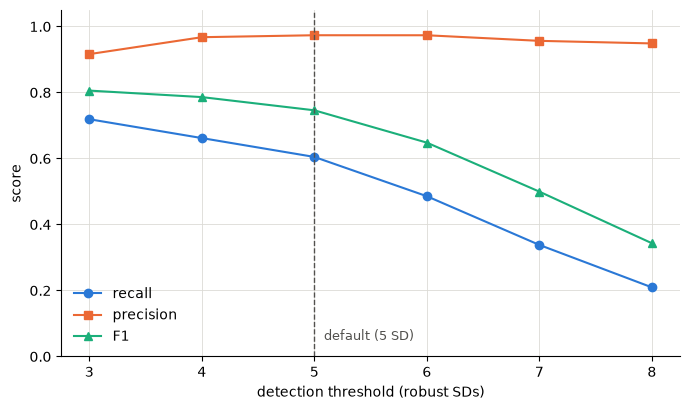

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(sweep["threshold_sd"], sweep["recall"], marker="o", color="#2a78d6", label="recall")
ax.plot(sweep["threshold_sd"], sweep["precision"], marker="s", color="#eb6834", label="precision")
ax.plot(sweep["threshold_sd"], sweep["f1"], marker="^", color="#1baf7a", label="F1")
ax.axvline(5, color="#52514e", linestyle="--", linewidth=1)
ax.text(5.05, 0.05, " default (5 SD)", color="#52514e", fontsize=9)
ax.set_xlabel("detection threshold (robust SDs)"); ax.set_ylabel("score")
ax.set_ylim(0, 1.05); ax.legend(frameon=False)
for side in ("top", "right"): ax.spines[side].set_visible(False)
ax.grid(color="#dcdbd6", linewidth=0.6); ax.set_axisbelow(True)
fig.tight_layout()

This curve is the honest description of a threshold detector: not "F1 = 0.74"
but "here is the trade-off, and here is why we chose 5". Quote the curve, not
the point.

## 5. Does artifact rejection earn its place?

The pipeline throws away a third of its own detections. That is only
justifiable if the ones it throws away are worse than the ones it keeps.

In [8]:
from onset_hfo.evaluate import validation_benefit

validation_benefit(result.events["rms"], recording.ground_truth).round(3)

,stage,n_detections,n_true_positives,n_false_positives,precision,recall,f1,false_positive_causes
0,raw detector output,238,129,88,0.630,0.614,0.622,"{'artifact': 86, 'spike': 2}"
1,after artifact rejection,151,127,4,0.974,0.605,0.746,"{'artifact': 3, 'spike': 1}"


Precision roughly 0.6 before, roughly 0.98 after; recall falls by a couple of
points. The `false_positive_causes` column names what was being confused —
`artifact` for filter ringing, `spike` for a discharge misread as an
oscillation. If that column ever showed mostly `background`, the detector
would be firing on noise and the thresholds would need to move.

## 6. Which criterion does the work?

Each check can be switched off. If a criterion costs recall and buys nothing,
it should be deleted rather than defended.

In [9]:
import pandas as pd
from onset_hfo.config import ValidationConfig
from onset_hfo.validate import validate_events

rows = []
for label, cfg in [
    ("no rejection at all", None),
    ("cycles only", ValidationConfig(min_peak_prominence_db=-99)),
    ("spectral peak only", ValidationConfig(min_cycles=0)),
    ("both (default)", ValidationConfig()),
]:
    events = detect_rms(prepared)
    if cfg is not None:
        validate_events(events, prepared, cfg)
    scores = evaluate_detections(events, recording.ground_truth, accepted_only=cfg is not None)
    rows.append({"stage": label, "kept": sum(e.accepted for e in events) if cfg else len(events),
                 "precision": round(scores.precision, 3), "recall": round(scores.recall, 3),
                 "f1": round(scores.f1, 3)})
pd.DataFrame(rows)

,stage,kept,precision,recall,f1
0,no rejection at all,238,0.630,0.614,0.622
1,cycles only,237,0.629,0.610,0.619
2,spectral peak only,152,0.974,0.610,0.750
3,both (default),151,0.974,0.605,0.746


## 7. Sensitivity to the recording, not just the settings

One seed is an anecdote. Three seeds with different noise and event placement
tell you whether the numbers are a property of the detector or of the
recording it happened to see.

In [10]:
rows = []
for seed in (1, 7, 42):
    rec = make_synthetic_recording(duration_s=60, seed=seed, verbose=False)
    res = run_pipeline(rec, verbose=False)
    for name, events in res.events.items():
        s = evaluate_detections(events, rec.ground_truth, detector=name)
        rows.append({"seed": seed, "detector": name, "precision": s.precision,
                     "recall": s.recall, "f1": s.f1})
    s = evaluate_detections(res.spikes, rec.ground_truth, detector="spike", kind="spike")
    rows.append({"seed": seed, "detector": "spike", "precision": s.precision,
                 "recall": s.recall, "f1": s.f1})
scores = pd.DataFrame(rows)
scores.groupby("detector")[["precision", "recall", "f1"]].agg(["mean", "std"]).round(3)

precision        recall            f1       
                 mean    std   mean    std   mean    std
detector                                                
line_length     0.957  0.017  0.550  0.078  0.697  0.067
rms             0.956  0.017  0.528  0.073  0.679  0.065
spike           0.998  0.004  0.844  0.037  0.914  0.023

## 8. How hard is the problem? Recall against SNR

The one parameter that matters most is how far the ripple stands above the
background. This is the curve to quote when someone asks "will it work on our
data?" — the answer depends on their signal-to-noise ratio, not on ours.

,ripple_snr,precision,recall,f1
0,4,0.821,0.195,0.315
1,5,0.896,0.283,0.430
2,6,0.938,0.403,0.563
3,7,0.960,0.585,0.727
4,9,0.972,0.774,0.861
5,12,0.978,0.918,0.947


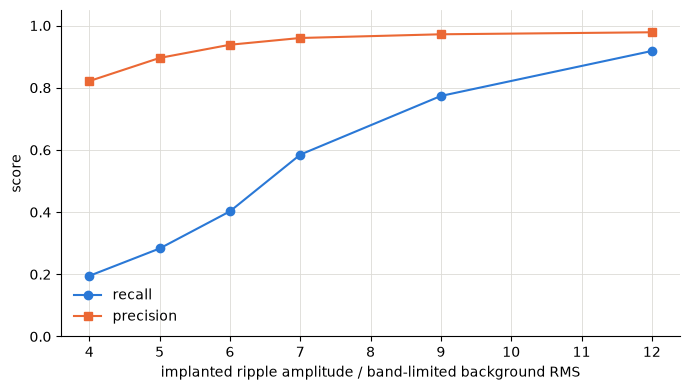

In [11]:
rows = []
for snr in (4, 5, 6, 7, 9, 12):
    rec = make_synthetic_recording(duration_s=45, seed=3, ripple_snr=snr, verbose=False)
    res = run_pipeline(rec, verbose=False)
    s = evaluate_detections(res.events["rms"], rec.ground_truth, detector="rms")
    rows.append({"ripple_snr": snr, "precision": s.precision, "recall": s.recall, "f1": s.f1})
snr_curve = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(snr_curve["ripple_snr"], snr_curve["recall"], marker="o", color="#2a78d6", label="recall")
ax.plot(snr_curve["ripple_snr"], snr_curve["precision"], marker="s", color="#eb6834", label="precision")
ax.set_xlabel("implanted ripple amplitude / band-limited background RMS")
ax.set_ylabel("score"); ax.set_ylim(0, 1.05); ax.legend(frameon=False)
for side in ("top", "right"): ax.spines[side].set_visible(False)
ax.grid(color="#dcdbd6", linewidth=0.6); ax.set_axisbelow(True)
fig.tight_layout()
snr_curve.round(3)

## What this does and does not establish

**Does:** the detectors find implanted oscillations well above chance; the
artifact rejection stage raises precision sharply at a small cost in recall;
the spike detector's discontinuity check removes the electrode-pop
false positives; the numbers are stable across recordings.

**Does not:** say anything about clinical performance. Real ripples are not
Gaussian-windowed sinusoids, real artifacts are more varied and more
creative, and real recordings have physiological ripples in healthy tissue
that no simulator here models. These scores are a floor on sanity, not a
measure of clinical utility.

The next step for this project — see `docs/ROADMAP.md` — is a small
hand-annotated subset of real recordings. That is the only thing that
converts these numbers into a claim about patients.